# 1. Fetching Data

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../data/spam.csv')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
732,ham,Lol you won't feel bad when I use her money to...,NaN,NaN,NaN
5463,ham,U GOIN OUT 2NITE?,NaN,NaN,NaN
412,ham,Okies... I'll go yan jiu too... We can skip ar...,NaN,NaN,NaN
360,ham,Ha ha cool cool chikku chikku:-):-DB-),NaN,NaN,NaN
1556,ham,Good sleep is about rhythm. The person has to ...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

# 2. Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# drop last 3 columns because they are mostly NULL
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [7]:
df.sample(5)

,v1,v2
859,ham,Did he just say somebody is named tampa
5379,ham,Somebody set up a website where you can play h...
2292,ham,:-( that's not v romantic!
2785,ham,Yeah get the unlimited
4309,spam,Someone U know has asked our dating service 2 ...


In [8]:
# renaming columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2816,spam,Gr8 Poly tones 4 ALL mobs direct 2u rply with ...
5335,ham,No. It's not pride. I'm almost &lt;#&gt; yea...
3169,ham,"Mah b, I'll pick it up tomorrow"
702,ham,What is important is that you prevent dehydrat...
28,ham,"I'm back &amp; we're packing the car now, I'll..."


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Checking for missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
# checking for duplicate values
df.duplicated().sum()

np.int64(403)

In [14]:
# removing duplicate
df= df.drop_duplicates(keep='first')

In [15]:
# re-checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(5169, 2)

# 3. EDA

In [17]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
# checking ratio of ham isto spam
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

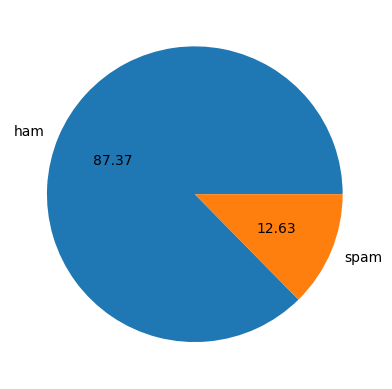

In [19]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [24]:
# Data is imbalanced

In [2]:
# for deeper analysis need three columns (a) no. of chars in sms (b) no. of words in sms (c) no. of sentances in sms.
# need to import nltk i.e. natural language tool kit.
# hence downloading it
!pip install --upgrade --force-reinstall nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached click-8.3.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached regex-2025.9.18-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Using cached regex-2025.9.18-cp311-cp311-win_amd64.whl (276 kB)
Using cached click-8.3.0-py3-none-any.whl (107 kB)
Using cached colorama-0.4.6-py2.py3-none-any.whl (25 kB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

  Attempting uninstall: regex

    Found existing installation: regex 2025.9.18

    Uninstalling regex-2025.9.18:

      Successfully uninstalled regex-2025.9.18

   ---------------------------------------- 0/6 [regex]
  Attempting uninstall: joblib
   --------------------------------

In [22]:
import nltk

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
# fetching and storing no. of characters in each sms
df['num_characters'] = df['text'].apply(len) 
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
# fetching and storing no. of words in each sms
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
# fetching and storing no. of sentenses in each sms
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
# describe for entire file
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# describe for ham sms
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# describe for spam sms
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


# 4. Data Preprocessing
* Lower Case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming

In [30]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
def transform_text(text):
    text = text.lower() # converting every text in to lowercase
    text = nltk.word_tokenize(text) # tokenizing each word and storing each word in text as list element

    y = []
    for i in text:
        if i.isalnum(): # filtering out alphabets and numbers and removing special symbols in the text
            y.append(i)
            
    text = y[:]  # this is done to avoid sharing same memory of differend variable i.e. if we do text = y, then copy of memory is done and any update in y will change text to
    y.clear() # clearing to reuse it
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: # filtering out from stopwords and punctuations
            y.append(i)
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i)) # stemming each word i.e. go, goes, going are all same word i.e. go
    return " ".join(y) # returning in the form of string

In [31]:
df['transformed_text'] = df['text'].apply(transform_text)

In [32]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# 5. Model Building

In [47]:
# Text Vectorization
# using Bag of Words i.e. comparing frequency of appearence of most common words in sms and counting the no. and storing into vectors
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 3000) # filtering out words whose count is more than 3000

In [48]:
X = tfidf.fit_transform(df['transformed_text']).toarray() # converting sparced array into dense array

In [49]:
X.shape

(5169, 3000)

In [50]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [52]:
# using naive bayes classifier because it is assumed to be one of the best algo for text classification

# importing multiple naive_bays algorithm because we don't know the distribution of out data
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB


# importing matrices for acuracy check
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [53]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [56]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2)) # best precision score i.e. 1

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [57]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [58]:
# chosen tfidf ---> mnb because best precision achieved

In [59]:
# model improrve
# 1. Change the max_features parameter of TfIdf in cell 153

In [64]:
# to perform required steps for user entered sms we need to pickle and use 
# 1. To transform text using trasform_text() fnx
# 2. To vectorize using tfidf vectorizer
# 3. To pass thorugh the model and predict it
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb')) # send with the name vectorizer.pkl write binary (wb) operation
pickle.dump(mnb,open('model.pkl','wb'))